# **Penting**
- Jangan mengubah atau menambahkan cell text yang sudah disediakan, Anda hanya perlu mengerjakan cell code yang sudah disediakan.
- Pastikan seluruh kriteria memiliki output yang sesuai, karena jika tidak ada output dianggap tidak selesai.
- Misal, Anda menggunakan df = df.dropna() silakan gunakan df.isnull().sum() sebagai tanda sudah berhasil. Silakan sesuaikan seluruh output dengan perintah yang sudah disediakan.
- Pastikan Anda melakukan Run All sebelum mengirimkan submission untuk memastikan seluruh cell berjalan dengan baik.
- Pastikan Anda menggunakan variabel df dari awal sampai akhir dan tidak diperbolehkan mengganti nama variabel tersebut.
- Hapus simbol pagar (#) pada kode yang bertipe komentar jika Anda menerapkan kriteria tambahan
- Biarkan simbol pagar (#) jika Anda tidak menerapkan kriteria tambahan
- Pastikan Anda mengerjakan sesuai section yang sudah diberikan tanpa mengubah judul atau header yang disediakan.

# **INFORMASI DATASET**

Dataset ini menyajikan gambaran mendalam mengenai perilaku transaksi dan pola aktivitas keuangan, sehingga sangat ideal untuk eksplorasi **deteksi penipuan (fraud detection)** dan **identifikasi anomali**. Dataset ini mencakup **2.512 sampel data transaksi**, yang mencakup berbagai atribut transaksi, demografi nasabah, dan pola penggunaan.

Setiap entri memberikan wawasan komprehensif terhadap perilaku transaksi, memungkinkan analisis untuk **keamanan finansial** dan pengembangan model prediktif.

## Fitur Utama

- **`TransactionID`**: Pengidentifikasi unik alfanumerik untuk setiap transaksi.  
- **`AccountID`**: ID unik untuk setiap akun, dapat memiliki banyak transaksi.  
- **`TransactionAmount`**: Nilai transaksi dalam mata uang, mulai dari pengeluaran kecil hingga pembelian besar.  
- **`TransactionDate`**: Tanggal dan waktu transaksi terjadi.  
- **`TransactionType`**: Tipe transaksi berupa `'Credit'` atau `'Debit'`.  
- **`Location`**: Lokasi geografis transaksi (nama kota di Amerika Serikat).  
- **`DeviceID`**: ID perangkat yang digunakan dalam transaksi.  
- **`IP Address`**: Alamat IPv4 yang digunakan saat transaksi, dapat berubah untuk beberapa akun.  
- **`MerchantID`**: ID unik merchant, menunjukkan merchant utama dan anomali transaksi.  
- **`AccountBalance`**: Saldo akun setelah transaksi berlangsung.  
- **`PreviousTransactionDate`**: Tanggal transaksi terakhir pada akun, berguna untuk menghitung frekuensi transaksi.  
- **`Channel`**: Kanal transaksi seperti `Online`, `ATM`, atau `Branch`.  
- **`CustomerAge`**: Usia pemilik akun.  
- **`CustomerOccupation`**: Profesi pengguna seperti `Dokter`, `Insinyur`, `Mahasiswa`, atau `Pensiunan`.  
- **`TransactionDuration`**: Lama waktu transaksi (dalam detik).  
- **`LoginAttempts`**: Jumlah upaya login sebelum transaksi—jumlah tinggi bisa mengindikasikan anomali.

Tugas kamu adalah membuat model clustering yang selanjutnya akan digunakan untuk membuat model klasifikasi.


# **1. Import Library**
Pada tahap ini, Anda perlu mengimpor beberapa pustaka (library) Python yang dibutuhkan untuk analisis data dan pembangunan model machine learning. Semua library yang dibutuhkan harus **import** di **cell** ini, jika ada library yang dijalankan di cell lain maka **submission langsung ditolak**

In [81]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder
import joblib
from sklearn.metrics import silhouette_score
from sklearn.cluster import KMeans
from yellowbrick.cluster import KElbowVisualizer
from sklearn.decomposition import PCA

# **2. Memuat Dataset**
Pada tahap ini, Anda perlu memuat dataset ke dalam notebook lalu mengecek informasi dataset sebelum nantinya dilakukan pembersihan. Hal-hal yang perlu dilakukan pada tahapan ini yaitu:
1. **Memahami Struktur Data**
   - Dataset harus mengambil referensi wajib digunakan (bisa dilihat [Disini](https://drive.google.com/drive/folders/1Zs7VmPZ-jNwsRlMKH65Ea-LApSwx6lKx?usp=drive_link))
   - Melakukan loading dataset ke dalam notebook dan menampilkan 5 baris pertama dengan function `head`.
   - Tinjau jumlah baris kolom dan jenis data dalam dataset dengan function `info`.  
   - Menampilkan statistik deskriptif dataset dengan menjalankan `describe`.
   - Pastikan **setiap function tersebut** memiliki **output pada setiap cell** code. Jika tidak **submission langsung ditolak**
   

Gunakan code ini untuk melakukan load data secara otomatis tanpa harus download data tersebut secara manual:
```python
url='https://drive.google.com/uc?id=1gnLO9qvEPqv1uBt1928AcsCmdvzqjC5m'
df = pd.read_csv(url)
```

Penting: pada kriteria pertama hindari penggunaan print() dan display() karena seluruh fungsi yang digunakan sudah memiliki standar output dan menghasilkan output yang diharapkan.

Kriteria 1 akan ditolak ketika:
- print(__.head())
- display(___.head())
dst

Kriteria 1 akan diterima ketika Anda menggunakan fungsi yang diminta tanpa menambahkan deskripsi apapun.

In [82]:
url='https://drive.google.com/uc?id=1gnLO9qvEPqv1uBt1928AcsCmdvzqjC5m'
df = pd.read_csv(url)

In [83]:
df.head()

,TransactionID,AccountID,TransactionAmount,TransactionDate,TransactionType,Location,DeviceID,IP Address,MerchantID,Channel,CustomerAge,CustomerOccupation,TransactionDuration,LoginAttempts,AccountBalance,PreviousTransactionDate
0,TX000001,AC00128,14.09,2023-04-11 16:29:14,Debit,San Diego,D000380,162.198.218.92,M015,ATM,70.0,Doctor,81.0,1.0,5112.21,2024-11-04 08:08:08
1,TX000002,AC00455,376.24,2023-06-27 16:44:19,Debit,Houston,D000051,13.149.61.4,M052,ATM,68.0,Doctor,141.0,1.0,13758.91,2024-11-04 08:09:35
2,TX000003,AC00019,126.29,2023-07-10 18:16:08,Debit,Mesa,D000235,215.97.143.157,M009,Online,19.0,Student,56.0,1.0,1122.35,2024-11-04 08:07:04
3,TX000004,AC00070,184.50,2023-05-05 16:32:11,Debit,Raleigh,D000187,200.13.225.150,M002,Online,26.0,Student,25.0,1.0,8569.06,2024-11-04 08:09:06
4,TX000005,AC00411,13.45,2023-10-16 17:51:24,Credit,Atlanta,D000308,65.164.3.100,M091,Online,NaN,Student,198.0,1.0,7429.40,2024-11-04 08:06:39


In [84]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2537 entries, 0 to 2536
Data columns (total 16 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   TransactionID            2508 non-null   object 
 1   AccountID                2516 non-null   object 
 2   TransactionAmount        2511 non-null   float64
 3   TransactionDate          2509 non-null   object 
 4   TransactionType          2507 non-null   object 
 5   Location                 2507 non-null   object 
 6   DeviceID                 2507 non-null   object 
 7   IP Address               2517 non-null   object 
 8   MerchantID               2514 non-null   object 
 9   Channel                  2510 non-null   object 
 10  CustomerAge              2519 non-null   float64
 11  CustomerOccupation       2514 non-null   object 
 12  TransactionDuration      2511 non-null   float64
 13  LoginAttempts            2516 non-null   float64
 14  AccountBalance          

In [85]:
df.describe(include='all')

,TransactionID,AccountID,TransactionAmount,TransactionDate,TransactionType,Location,DeviceID,IP Address,MerchantID,Channel,CustomerAge,CustomerOccupation,TransactionDuration,LoginAttempts,AccountBalance,PreviousTransactionDate
count,2508,2516,2511.000000,2509,2507,2507,2507,2517,2514,2510,2519.000000,2514,2511.000000,2516.000000,2510.000000,2513
unique,2484,495,NaN,2485,2,43,681,591,100,3,NaN,4,NaN,NaN,NaN,360
top,TX000076,AC00362,NaN,2023-12-25 17:31:16,Debit,Fort Worth,D000573,200.136.146.93,M026,Branch,NaN,Student,NaN,NaN,NaN,2024-11-04 08:09:17
freq,2,12,NaN,2,1942,71,9,12,46,868,NaN,657,NaN,NaN,NaN,18
mean,NaN,NaN,297.656468,NaN,NaN,NaN,NaN,NaN,NaN,NaN,44.678444,NaN,119.422939,1.121622,5113.438124,NaN
std,NaN,NaN,292.230367,NaN,NaN,NaN,NaN,NaN,NaN,NaN,17.837359,NaN,70.078513,0.594469,3897.975861,NaN
min,NaN,NaN,0.260000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,18.000000,NaN,10.000000,1.000000,101.250000,NaN
25%,NaN,NaN,81.310000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,27.000000,NaN,63.000000,1.000000,1504.727500,NaN
50%,NaN,NaN,211.360000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,45.000000,NaN,112.000000,1.000000,4734.110000,NaN
75%,NaN,NaN,413.105000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,59.000000,NaN,161.000000,1.000000,7672.687500,NaN


(Opsional) Memuat Dataset dan Melakukan Exploratory Data Analysis (EDA) [Skilled]

**Biarkan kosong jika tidak menerapkan kriteria skilled**

**Apabila ingin menerapkan Advanced, pastikan seluruh visualisasi tidak ada yang overlap**

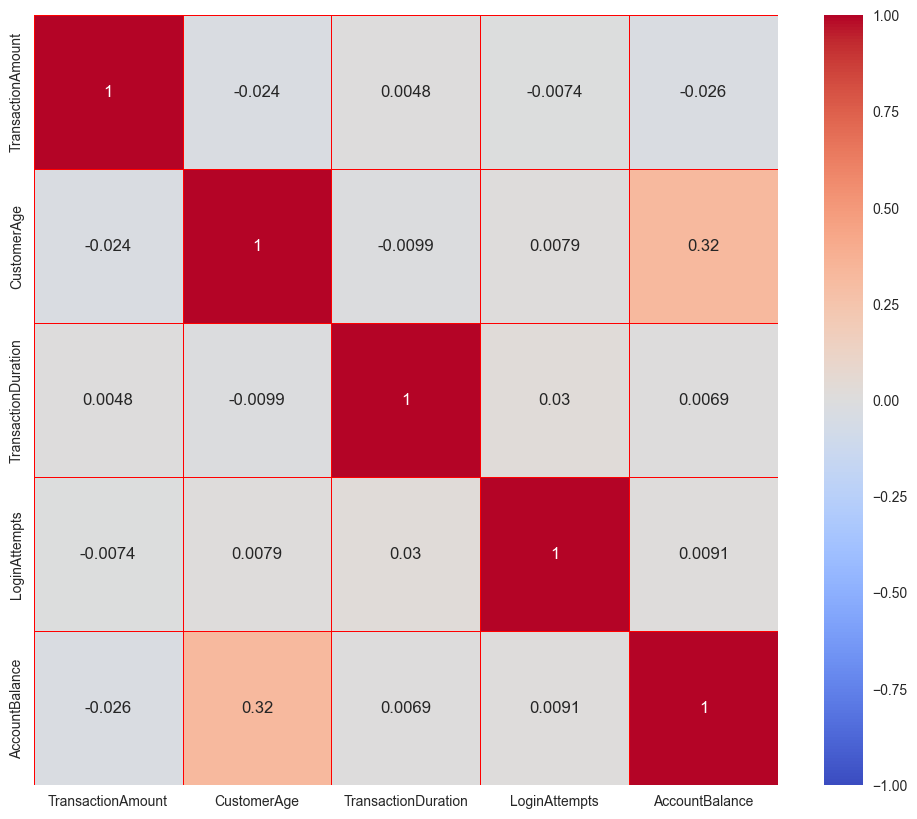

In [86]:
plt.figure(figsize=(12, 10))
correlation_matrix = df.select_dtypes(include=['number']).corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1, linewidths=0.5, linecolor="red")
plt.show()

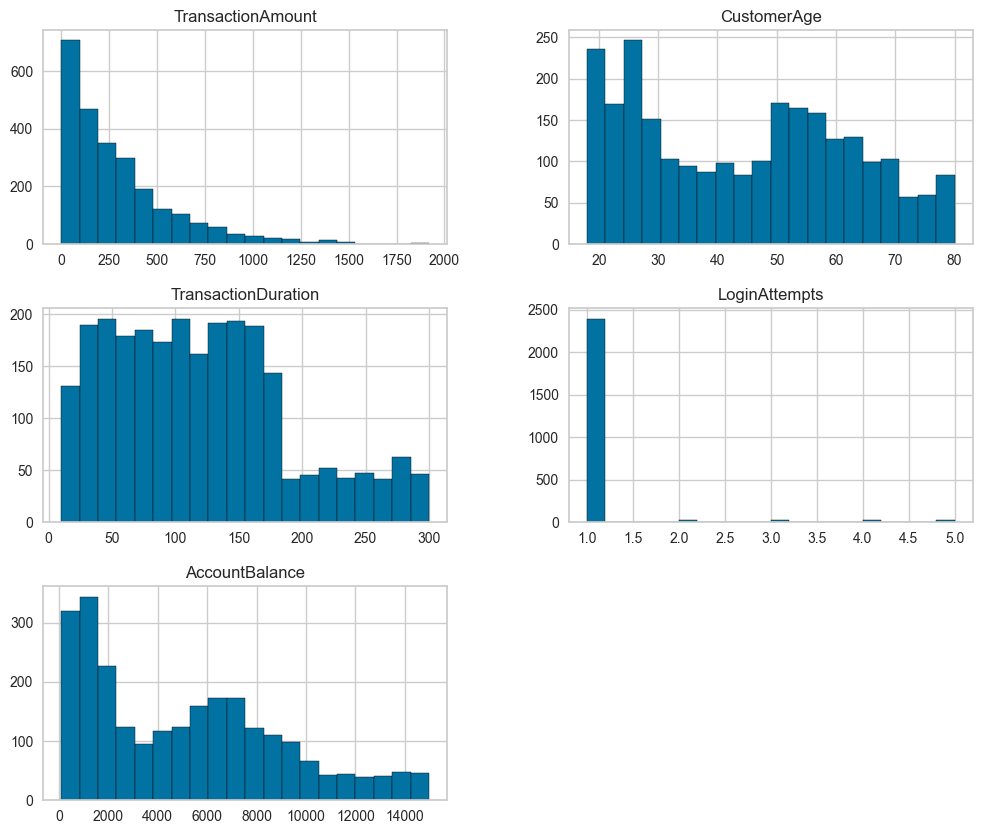

In [87]:
df.hist(figsize=(12, 10), bins=20, edgecolor='black')
plt.show()

(Opsional) Memuat Dataset dan Melakukan Exploratory Data Analysis (EDA) [Advanced]

**Biarkan kosong jika tidak menerapkan kriteria advanced**

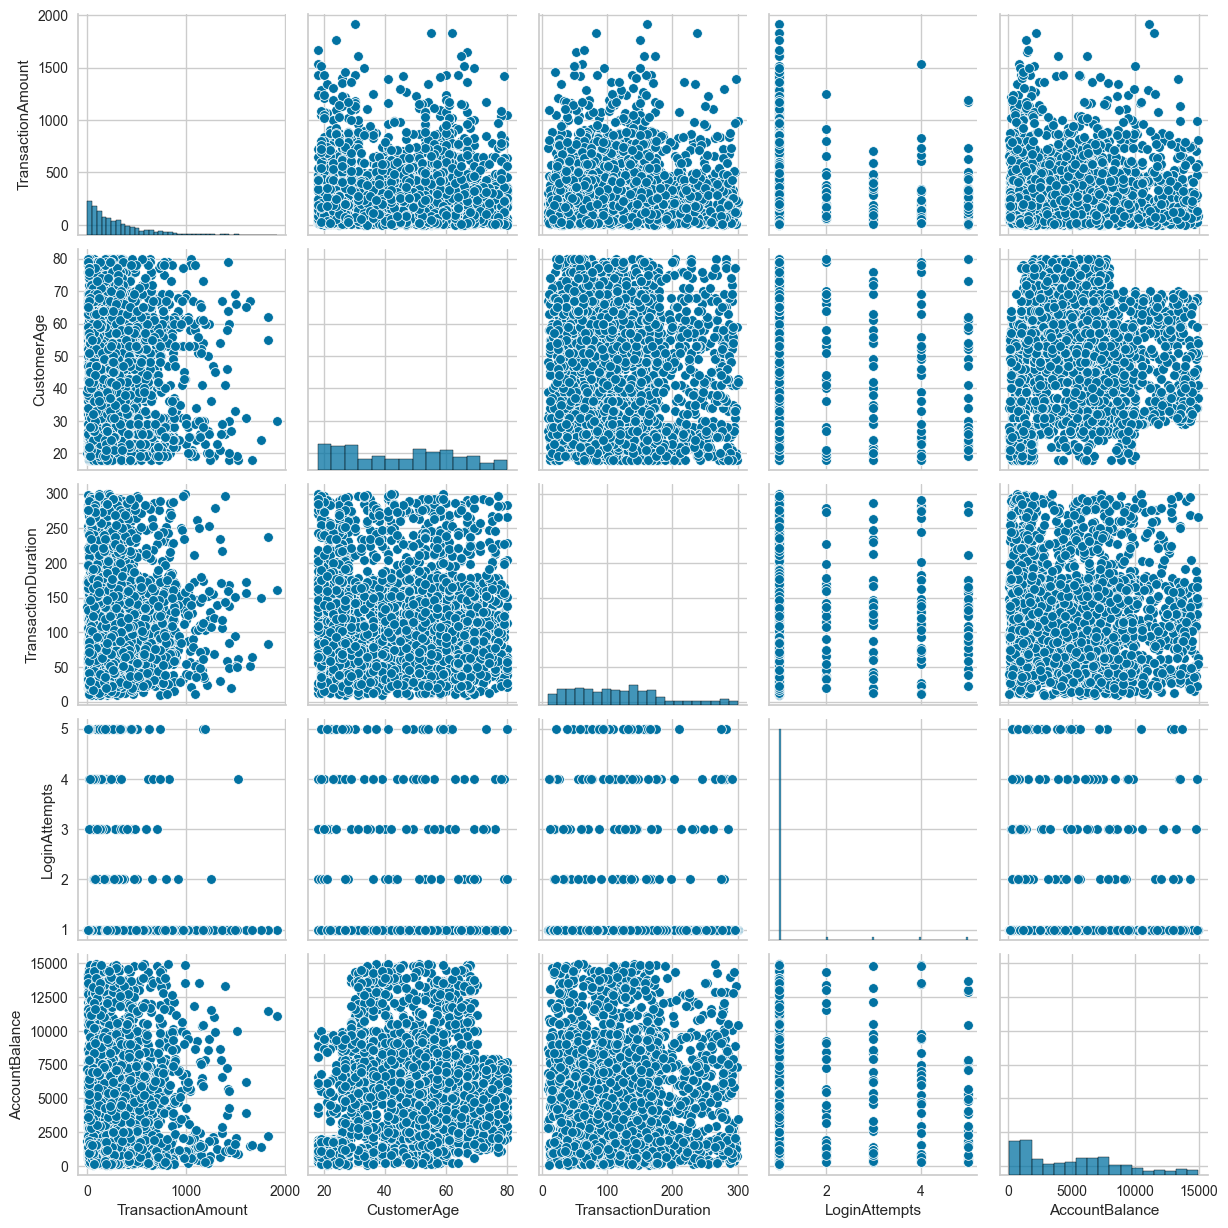

In [88]:
sns.pairplot(df)

# **3. Pembersihan dan Pra Pemrosesan Data**

Pada tahap ini, Anda akan melakukan **Pembersihan Dataset** untuk menjadikan dataset mudah diintepretasi dan bisa dilatih. Hal-hal yang wajib kamu lakukan yaitu:

1. **Mengecek dataset** menggunakan isnull().sum() dan duplicated().sum().
2. Melakukan feature scaling menggunakan `MinMaxScaler()` atau `StandardScalar()` untuk fitur numerik.
3. Melakukan feature encoding menggunakan `LabelEncoder()` untuk fitur kategorikal.
4. Melakukan drop pada kolom id.
5. **Ketentuan Cell Code**
   - Pastikan **setiap pemeriksaan tersebut** memiliki **output pada cell-nya**. Jika tidak **submission langsung ditolak**


In [89]:
missing_values = df.isnull().sum()
missing_values[missing_values > 0]

TransactionID              29
AccountID                  21
TransactionAmount          26
TransactionDate            28
TransactionType            30
Location                   30
DeviceID                   30
IP Address                 20
MerchantID                 23
Channel                    27
CustomerAge                18
CustomerOccupation         23
TransactionDuration        26
LoginAttempts              21
AccountBalance             27
PreviousTransactionDate    24
dtype: int64

In [90]:
df.duplicated().sum()

np.int64(21)

In [91]:
numerical_cols = df.select_dtypes(include=['number']).columns
scaler = StandardScaler()
df[numerical_cols] = scaler.fit_transform(df[numerical_cols])
df.head()

,TransactionID,AccountID,TransactionAmount,TransactionDate,TransactionType,Location,DeviceID,IP Address,MerchantID,Channel,CustomerAge,CustomerOccupation,TransactionDuration,LoginAttempts,AccountBalance,PreviousTransactionDate
0,TX000001,AC00128,-0.970546,2023-04-11 16:29:14,Debit,San Diego,D000380,162.198.218.92,M015,ATM,1.419862,Doctor,-0.548393,-0.204629,-0.000315,2024-11-04 08:08:08
1,TX000002,AC00455,0.268963,2023-06-27 16:44:19,Debit,Houston,D000051,13.149.61.4,M052,ATM,1.307715,Doctor,0.307960,-0.204629,2.218381,2024-11-04 08:09:35
2,TX000003,AC00019,-0.586526,2023-07-10 18:16:08,Debit,Mesa,D000235,215.97.143.157,M009,Online,-1.439874,Student,-0.905207,-0.204629,-1.024091,2024-11-04 08:07:04
3,TX000004,AC00070,-0.387294,2023-05-05 16:32:11,Debit,Raleigh,D000187,200.13.225.150,M002,Online,-1.047361,Student,-1.347656,-0.204629,0.886694,2024-11-04 08:09:06
4,TX000005,AC00411,-0.972736,2023-10-16 17:51:24,Credit,Atlanta,D000308,65.164.3.100,M091,Online,NaN,Student,1.121495,-0.204629,0.594263,2024-11-04 08:06:39


In [92]:
df = df.drop(columns=["TransactionID", "AccountID", "DeviceID", "MerchantID", "IP Address"])
df.head()

,TransactionAmount,TransactionDate,TransactionType,Location,Channel,CustomerAge,CustomerOccupation,TransactionDuration,LoginAttempts,AccountBalance,PreviousTransactionDate
0,-0.970546,2023-04-11 16:29:14,Debit,San Diego,ATM,1.419862,Doctor,-0.548393,-0.204629,-0.000315,2024-11-04 08:08:08
1,0.268963,2023-06-27 16:44:19,Debit,Houston,ATM,1.307715,Doctor,0.307960,-0.204629,2.218381,2024-11-04 08:09:35
2,-0.586526,2023-07-10 18:16:08,Debit,Mesa,Online,-1.439874,Student,-0.905207,-0.204629,-1.024091,2024-11-04 08:07:04
3,-0.387294,2023-05-05 16:32:11,Debit,Raleigh,Online,-1.047361,Student,-1.347656,-0.204629,0.886694,2024-11-04 08:09:06
4,-0.972736,2023-10-16 17:51:24,Credit,Atlanta,Online,NaN,Student,1.121495,-0.204629,0.594263,2024-11-04 08:06:39


In [93]:
categorical_cols = df.select_dtypes(include=['object']).columns
encoders = {}
for col in categorical_cols:
    label_encoder = LabelEncoder()
    df[col] = label_encoder.fit_transform(df[col])
    encoders[col] = label_encoder
df.head()

,TransactionAmount,TransactionDate,TransactionType,Location,Channel,CustomerAge,CustomerOccupation,TransactionDuration,LoginAttempts,AccountBalance,PreviousTransactionDate
0,-0.970546,680,1,36,0,1.419862,0,-0.548393,-0.204629,-0.000315,105
1,0.268963,1178,1,15,0,1.307715,0,0.307960,-0.204629,2.218381,192
2,-0.586526,1262,1,23,2,-1.439874,3,-0.905207,-0.204629,-1.024091,41
3,-0.387294,818,1,33,2,-1.047361,3,-1.347656,-0.204629,0.886694,163
4,-0.972736,1939,0,1,2,NaN,3,1.121495,-0.204629,0.594263,16


In [94]:
df.columns.tolist()

['TransactionAmount',
 'TransactionDate',
 'TransactionType',
 'Location',
 'Channel',
 'CustomerAge',
 'CustomerOccupation',
 'TransactionDuration',
 'LoginAttempts',
 'AccountBalance',
 'PreviousTransactionDate']

(Opsional) Pembersihan dan Pra Pemrosesan Data [Skilled]

**Biarkan kosong jika tidak menerapkan kriteria skilled**

In [95]:
df = df.dropna()
df.isnull().sum()

TransactionAmount          0
TransactionDate            0
TransactionType            0
Location                   0
Channel                    0
CustomerAge                0
CustomerOccupation         0
TransactionDuration        0
LoginAttempts              0
AccountBalance             0
PreviousTransactionDate    0
dtype: int64

In [96]:
df.drop_duplicates()
print(df)

      TransactionAmount  TransactionDate  TransactionType  Location  Channel  \
0             -0.970546              680                1        36        0   
1              0.268963             1178                1        15        0   
2             -0.586526             1262                1        23        2   
3             -0.387294              818                1        33        2   
5             -0.703375              635                1        28        0   
...                 ...              ...              ...       ...      ...   
2532          -0.231290              781                1         2        2   
2533           0.903315             1154                1        34        2   
2534           0.668967             1380                1         7        1   
2535          -0.338966              865                0        40        1   
2536          -0.993135             1979                0        15        2   

      CustomerAge  CustomerOccupation  

(Opsional) Pembersihan dan Pra Pemrosesan Data [Advanced]

**Biarkan kosong jika tidak menerapkan kriteria advanced**

In [97]:
Q1 = df[numerical_cols].quantile(0.25)
Q3 = df[numerical_cols].quantile(0.75)
IQR = Q3 - Q1
condition = ~((df[numerical_cols] < (Q1 - 1.5 * IQR)) | (df[numerical_cols] > (Q3 + 1.5 * IQR))).any(axis=1)
df_filtered_numeric = df.loc[condition, numerical_cols]
categorical_features = df.select_dtypes(include=['object']).columns
df = pd.concat([df_filtered_numeric, df.loc[condition, categorical_features]], axis=1)

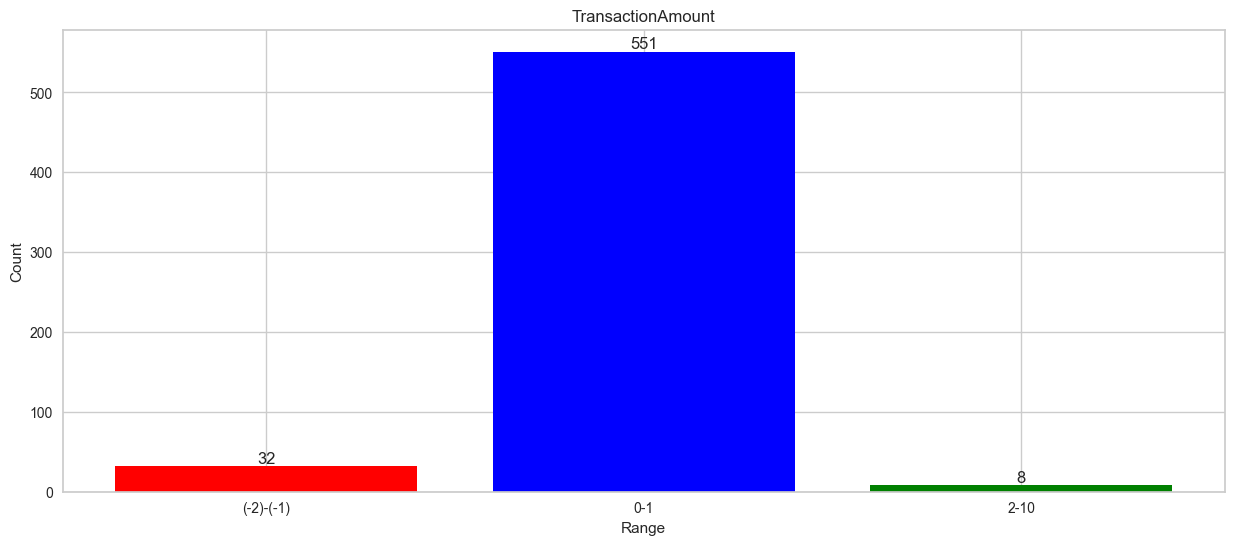

,TransactionAmount,CustomerAge,TransactionDuration,LoginAttempts,AccountBalance,TransactionAmount_Encoded
0,-0.970546,1.419862,-0.548393,-0.204629,-0.000315,94
1,0.268963,1.307715,0.307960,-0.204629,2.218381,1595
2,-0.586526,-1.439874,-0.905207,-0.204629,-1.024091,774
3,-0.387294,-1.047361,-1.347656,-0.204629,0.886694,1006
5,-0.703375,-1.495947,0.750409,-0.204629,-1.111505,597


In [98]:
TransactionAmount0 = df.TransactionAmount[(df.TransactionAmount >= -2) & (df.TransactionAmount <= -1)]
TransactionAmount1 = df.TransactionAmount[(df.TransactionAmount >= 0) & (df.TransactionAmount <= 1)]
TransactionAmount2 = df.TransactionAmount[(df.TransactionAmount >= 2) & (df.TransactionAmount <= 10)]
x = ["(-2)-(-1)", "0-1", "2-10"]
y = [len(TransactionAmount0), len(TransactionAmount1), len(TransactionAmount2)]
plt.figure(figsize=(15, 6))
plt.bar(x, y, color=['red', 'blue', 'green'])
plt.title("TransactionAmount")
plt.xlabel("Range")
plt.ylabel("Count")
for i in range(len(x)):
  plt.text(i, y[i], y[i], ha='center', va='bottom')
plt.show()
df["TransactionAmount_Encoded"] = label_encoder.fit_transform(df["TransactionAmount"])
df.head()

# **4. Membangun Model Clustering**
Pada tahap ini, Anda membangun model clustering dengan memilih algoritma yang sesuai untuk mengelompokkan data berdasarkan kesamaan.
1. Pastikan Anda menggunakan dataframe yang sudah melalui processing sesuai dengan levelnya (Basic, Skilled, Advanced)
2. Melakukan visualisasi Elbow Method untuk menentukan jumlah cluster terbaik menggunakan `KElbowVisualizer()`.
3. Menggunakan algoritma K-Means Clustering dengan `sklearn.cluster.KMeans()`.
4. Jalankan cell code `joblib.dump(model_kmeans, "model_clustering.h5")` untuk menyimpan model yang sudah dibuat.

In [99]:
df.describe()

,TransactionAmount,CustomerAge,TransactionDuration,LoginAttempts,AccountBalance,TransactionAmount_Encoded
count,2204.000000,2204.000000,2204.000000,2204.000000,2204.000000,2204.000000
mean,-0.142945,-0.000287,-0.011806,-0.204629,-0.003781,1059.971416
std,0.742899,0.996038,1.000544,0.000000,0.996508,617.883544
min,-1.017881,-1.495947,-1.561745,-0.204629,-1.286100,0.000000
25%,-0.751557,-0.991288,-0.819572,-0.204629,-0.926581,522.750000
50%,-0.336194,0.018031,-0.134489,-0.204629,-0.103488,1060.500000
75%,0.266935,0.803056,0.593411,-0.204629,0.644878,1594.250000
max,2.072523,1.980594,2.577295,-0.204629,2.531190,2133.000000


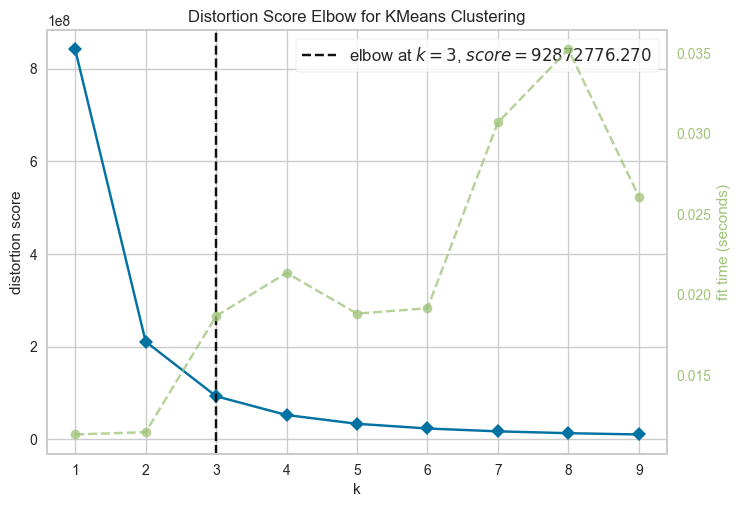

<Axes: title={'center': 'Distortion Score Elbow for KMeans Clustering'}, xlabel='k', ylabel='distortion score'>

In [100]:
X = df.select_dtypes(include=['number'])
kmeans = KMeans()
visualizer = KElbowVisualizer(kmeans, k=(1, 10))
visualizer.fit(X)
visualizer.show()

In [101]:
X = df.select_dtypes(include=['number'])
kmeans = KMeans(n_clusters=3, random_state=42)
df['Cluster'] = kmeans.fit_predict(X)
print(df['Cluster'].value_counts())
df[['Cluster'] + X.columns.tolist()].head()


Cluster
2    736
0    735
1    733
Name: count, dtype: int64


,Cluster,TransactionAmount,CustomerAge,TransactionDuration,LoginAttempts,AccountBalance,TransactionAmount_Encoded
0,2,-0.970546,1.419862,-0.548393,-0.204629,-0.000315,94
1,1,0.268963,1.307715,0.307960,-0.204629,2.218381,1595
2,0,-0.586526,-1.439874,-0.905207,-0.204629,-1.024091,774
3,0,-0.387294,-1.047361,-1.347656,-0.204629,0.886694,1006
5,2,-0.703375,-1.495947,0.750409,-0.204629,-1.111505,597


Jalankan cell code ini untuk menyimpan model kamu.

In [102]:
joblib.dump(kmeans, "model_clustering.h5")

['model_clustering.h5']

(Opsional) Membangun Model Clustering [Skilled]

**Biarkan kosong jika tidak menerapkan kriteria skilled**

In [103]:
X = df.select_dtypes(include=['number'])
kmeans = KMeans(n_clusters=3, random_state=42)
df['Cluster'] = kmeans.fit_predict(X)
score = silhouette_score(X, df['Cluster'])
print(score)

0.5910834585161607


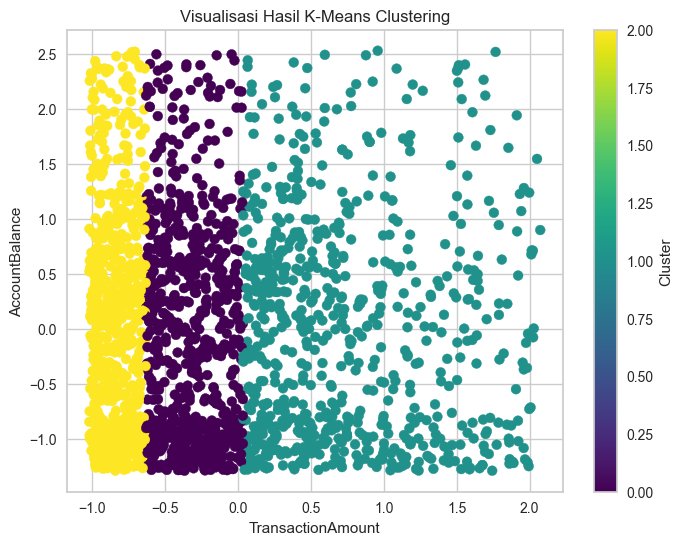

In [104]:
plt.figure(figsize=(8,6))
x_col = 'TransactionAmount'
y_col = 'AccountBalance'
plt.scatter(df[x_col], df[y_col], c=df['Cluster'], cmap='viridis', s=50)
plt.xlabel(x_col)
plt.ylabel(y_col)
plt.title("Visualisasi Hasil K-Means Clustering")
plt.colorbar(label="Cluster")
plt.show()

(Opsional) Membangun Model Clustering [Advanced]

**Biarkan kosong jika tidak menerapkan kriteria advanced**

In [105]:
pca = PCA(n_components=2)
pca_data = pca.fit_transform(X)
data_final = pd.DataFrame(pca_data, columns=['PCA1', 'PCA2'])
kmeans_pca = KMeans(n_clusters=3, random_state=0)
kmeans_pca.fit(data_final)

,n_clusters,3
,init,'k-means++'
,n_init,'auto'
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,0
,copy_x,True
,algorithm,'lloyd'


In [106]:
joblib.dump(kmeans_pca, "PCA_model_clustering.h5")

['PCA_model_clustering.h5']

# **5. Interpretasi Cluster**

## **a. Interpretasi Hasil Clustering**
1. **Contoh Interpretasi:**
- **Cluster 1: (Nasabah Bertransaksi dan Pendapatan Besar)**:
  - **Rata-rata (mean) Annual Income:** 0.953 (48,260)
  - **Rata-rata (mean) Spending Score:** 0.8 (56.48)
  - **Analisis:** Cluster ini mencakup pelanggan dengan pendapatan tahunan tinggi dan tingkat pengeluaran yang cukup tinggi. Pelanggan dalam cluster ini cenderung memiliki daya beli yang tinggi dan mereka lebih cenderung untuk membelanjakan sebagian besar pendapatan mereka. Sehingga rekomendasi pada kelompok nasabah ini adalah dengan menawarkan produk-produk investasi atau perbankan yang berkualitas tinggi.


## Menjelaskan karakteristik tiap cluster berdasarkan rentangnya.
1. **Cluster 0: (transaksi sedang, saldo rendah)**:
  - **TransactionAmount:**
  - Mean: -0.32 → sedikit di bawah rata-rata (transaksi relatif kecil)
  - Min: -0.63 → lebih rendah dibanding rata-rata
  - Max: 0.03 → hampir mendekati normal
  - **CustomerAge:**
  - Mean: -0.02 → mendekati rata-rata
  - Min: -1.49 (usia termuda dalam data)
  - Max: 1.98 (usia tertua dalam data)
  - **TransactionDuration:**
  - Mean: 0.02 → normal
  - Min: -1.56 → durasi sangat cepat
  - Max: 2.58 → durasi sangat lama
  - **LoginAttempts:** konstan -0.20 → stabil (tidak bervariasi)
  - **AccountBalance:**
  - Mean: -0.03 → sedikit di bawah rata-rata (saldo agak lebih rendah)
  - Min: -1.29 → saldo sangat rendah
  - Max: 2.50 → saldo sangat tinggi
  - **Analisis :**
  Cluster ini memiliki pola transaksi dengan jumlah yang tidak terlalu kecil namun juga tidak terlalu besar, berada di tingkat menengah. Durasi transaksi relatif lebih lama, sementara jumlah percobaan login stabil. Saldo rekening mereka cukup kecil, menunjukkan bahwa nasabah di cluster ini adalah pelanggan dengan tabungan rendah, namun stabil dalam bertransaksi.

2. **Cluster 1: (transaksi besar, saldo sedang)**:
  - **TransactionAmount:** Mean: 0.74 → jauh di atas rata-rata (transaksi besar)
  - Min: 0.04 → di atas rata-rata
  - Max: 2.07 → sangat tinggi
  - **CustomerAge:**
  - Mean: -0.02 → mendekati normal
  - Rentang sama (min -1.49, max 1.98)
  - **TransactionDuration:**
  - Mean: -0.02 → normal
  - Min: -1.56 → cepat
  - Max: 2.52 → lama
  - **LoginAttempts:** konstan -0.20 → stabil
  - **AccountBalance:**
  - Mean: 0.00 → seimbang dengan rata-rata
  - Min: -1.29
  - Max: 2.53
  - **Analisis:** Nasabah di cluster ini ditandai dengan nilai transaksi yang cenderung tinggi. Durasi transaksi berlangsung cukup lama dengan pola login yang tetap stabil. Saldo rekening mereka termasuk tinggi, mencerminkan kapasitas finansial cukup besar. Cluster ini menggambarkan nasabah premium yang potensial untuk diberikan layanan eksklusif atau prioritas.

3. **Cluster 2: (transaksi kecil, saldo tinggi)**:
  - TransactionAmount:
  - Mean: -0.84 → jauh di bawah rata-rata (transaksi kecil)
  - Min: -1.02 → sangat rendah
  - Max: -0.63 → tetap rendah
  - **CustomerAge:**
  - Mean: -0.03 → mendekati rata-rata
  - Rentang sama (min -1.49, max 1.98)
  - **TransactionDuration:**
  - Mean: -0.03 → normal
  - Min: -1.56 → cepat
  - Max: 2.55 → lama
  - **LoginAttempts:** konstan -0.20
  - **AccountBalance:**
  - Mean: 0.01 → sedikit di atas rata-rata
  - Min: -1.29
  - Max: 2.52
  - **Analisis:** Cluster ini dapat dikategorikan sebagai nasabah pasif penyimpan dana, yakni mereka jarang bertransaksi tetapi menyimpan saldo paling besar besar, durasi transaksi cenderung lebih singkat, dengan login yang tetap konsisten, sehingga cenderung lebih berperan sebagai deposan daripada pengguna aktif layanan transaksi.


In [107]:
df.groupby("Cluster")[df.select_dtypes(include=["int64", "float64"]).columns] \
  .agg(["mean", "min", "max"])

TransactionAmount                     CustomerAge                      \
                     mean       min       max        mean       min       max   
Cluster                                                                         
0               -0.323048 -0.630164  0.035026   -0.015918 -1.495947  1.980594   
1                0.739699  0.036189  2.072523   -0.004950 -1.495947  1.980594   
2               -0.839988 -1.017881 -0.631910    0.019933 -1.495947  1.980594   

        TransactionDuration                     LoginAttempts            \
                       mean       min       max          mean       min   
Cluster                                                                   
0                  0.018140 -1.561745  2.577295     -0.204629 -0.204629   
1                 -0.022824 -1.561745  2.520205     -0.204629 -0.204629   
2                 -0.030728 -1.561745  2.548750     -0.204629 -0.204629   

                  AccountBalance                      \
              max           mean       min       max   
Cluster                                                
0       -0.204629      -0.025681 -1.286100  2.498969   
1       -0.204629       0.000535 -1.285856  2.531190   
2       -0.204629       0.013773 -1.285135  2.522155   

        TransactionAmount_Encoded              
                             mean   min   max  
Cluster                                        
0                     1062.634014   705  1417  
1                     1774.739071  1418  2133  
2                      347.397558     0   704

# **6. Mengeksport Data**

1. Simpan nama kolom hasil clustering dengan nama `Target`.
2. Simpan hasilnya ke dalam file CSV menggunakan function `to_csv()`.

In [108]:
df.rename(columns={'Cluster': 'Target'}, inplace=True)

In [109]:
df.to_csv('data_clustering.csv', index=False)
df.head()

,TransactionAmount,CustomerAge,TransactionDuration,LoginAttempts,AccountBalance,TransactionAmount_Encoded,Target
0,-0.970546,1.419862,-0.548393,-0.204629,-0.000315,94,2
1,0.268963,1.307715,0.307960,-0.204629,2.218381,1595,1
2,-0.586526,-1.439874,-0.905207,-0.204629,-1.024091,774,0
3,-0.387294,-1.047361,-1.347656,-0.204629,0.886694,1006,0
5,-0.703375,-1.495947,0.750409,-0.204629,-1.111505,597,2


(Opsional) Interpretasi Hasil Clustering [Skilled]

**Biarkan kosong jika tidak menerapkan kriteria skilled**

In [110]:
df[numerical_cols] = scaler.inverse_transform(df[numerical_cols])
df.head()

,TransactionAmount,CustomerAge,TransactionDuration,LoginAttempts,AccountBalance,TransactionAmount_Encoded,Target
0,14.09,70.0,81.0,1.0,5112.21,94,2
1,376.24,68.0,141.0,1.0,13758.91,1595,1
2,126.29,19.0,56.0,1.0,1122.35,774,0
3,184.50,26.0,25.0,1.0,8569.06,1006,0
5,92.15,18.0,172.0,1.0,781.68,597,2


In [111]:
for col in categorical_cols:
    if col in df.columns:
        le = encoders[col]
        df[col] = le.inverse_transform(df[col].astype(int))
df.head()

,TransactionAmount,CustomerAge,TransactionDuration,LoginAttempts,AccountBalance,TransactionAmount_Encoded,Target
0,14.09,70.0,81.0,1.0,5112.21,94,2
1,376.24,68.0,141.0,1.0,13758.91,1595,1
2,126.29,19.0,56.0,1.0,1122.35,774,0
3,184.50,26.0,25.0,1.0,8569.06,1006,0
5,92.15,18.0,172.0,1.0,781.68,597,2


In [112]:
df.groupby("Target")[df.select_dtypes(include=["int64", "float64"]).columns] \
  .agg(["mean", "min", "max"])

TransactionAmount                 CustomerAge              \
                    mean     min     max        mean   min   max   
Target                                                             
0             203.270925  113.54  307.89   44.394558  18.0  80.0   
1             513.775874  308.23  903.19   44.590164  18.0  80.0   
2              52.235346    0.26  113.03   45.033921  18.0  80.0   

       TransactionDuration              LoginAttempts            \
                      mean   min    max          mean  min  max   
Target                                                            
0               120.693878  10.0  300.0           1.0  1.0  1.0   
1               117.823770  10.0  296.0           1.0  1.0  1.0   
2               117.270014  10.0  298.0           1.0  1.0  1.0   

       AccountBalance                   TransactionAmount_Encoded              
                 mean     min       max                      mean   min   max  
Target                                                                         
0         5013.353878  101.25  14852.42               1062.634014   705  1417  
1         5115.522978  102.20  14977.99               1774.739071  1418  2133  
2         5167.114559  105.01  14942.78                347.397558     0   704

## Menjelaskan karakteristik tiap cluster berdasarkan rentangnya setelah inverse.
1. **Cluster 0: (transaksi sedang dan saldo tinggi)**:
  - **TransactionAmount:**
  - Mean: 203 (transaksi kecil–sedang)
  - Min: 113 (transaksi paling kecil)
  - Max: 307 (transaksi tertinggi dalam cluster ini)
  - **CustomerAge:**
  - Mean: 44 tahun
  - Min: 18 (usia termuda)
  - Max: 80 (usia tertua)
  - **TransactionDuration:**
  - Mean: 121 (cukup lama)
  - Min: 10 (paling cepat)
  - Max: 300 (paling lama)
  - **LoginAttempts:** selalu 1
  - **AccountBalance:**
  - Mean: 5013 (cukup tinggi)
  - Min: 101 (saldo minimum)
  - Max: 14852 (saldo maksimum)
  - **Analisis :**
Sama seperti pada data standar, kelompok ini adalah nasabah reguler mapan yang bertransaksi pada jumlah sedang dengan saldo cukup tinggi.

2. **Cluster 1 (transaksi besar dan saldo tertinggi)**:
  - **TransactionAmount:**
  - Mean: 514 (sedang–besar)
  - Min: 308 (paling kecil)
  - Max: 903 (paling besar)
  - **CustomerAge:**
  - Mean: 44 tahun
  - Min: 18
  - Max: 80
  - **TransactionDuration:**
  - Mean: 118
  - Min: 10
  - Max: 296
  - **LoginAttempts:** selalu 1
  - **AccountBalance:**
  - Mean: 5116
  - Min: 102
  - Max: 14977
  - **Analisis:** Nasabah ini merupakan premium aktif, sering bertransaksi dengan nominal besar dan memiliki saldo tinggi, mirip hasil standarisasi.

3. **Cluster 2 (transaksi rendah tapi saldo tinggi)**:
  - **TransactionAmount:**
  - Mean: 52 (sangat kecil)
  - Min: 0 (tidak ada transaksi pada beberapa nasabah)
  - Max: 113 (tertinggi di cluster ini tetap kecil)
  - **CustomerAge:**
  - Mean: 45 tahun (sedikit lebih tua)
  - Min: 18
  - Max: 80
  - **TransactionDuration:**
  - Mean: 117
  - Min: 10
  - Max: 298
  - **LoginAttempts:** selalu 1
  - **AccountBalance:**
  - Mean: 5167
  - Min: 105
  - Max: 14942
  - **Analisis :**
Nasabah ini pasif, jarang bertransaksi tetapi memiliki saldo yang besar, sehingga lebih cocok dipandang sebagai kelompok penyimpan dana.

(Opsional) Interpretasi Hasil Clustering [Advanced]

**Biarkan kosong jika tidak menerapkan kriteria advanced**

In [113]:
df = df.reset_index(drop=True)
clusters = df['Target'].reset_index(drop=True)
df_final = df.copy()
df_final['Target'] = clusters
df_final.head()

,TransactionAmount,CustomerAge,TransactionDuration,LoginAttempts,AccountBalance,TransactionAmount_Encoded,Target
0,14.09,70.0,81.0,1.0,5112.21,94,2
1,376.24,68.0,141.0,1.0,13758.91,1595,1
2,126.29,19.0,56.0,1.0,1122.35,774,0
3,184.50,26.0,25.0,1.0,8569.06,1006,0
4,92.15,18.0,172.0,1.0,781.68,597,2


In [114]:
df.to_csv('data_clustering_inverse.csv', index=False)

End of Code.